In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'speed-accuracy_trade-off')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
pilot_analysis = True
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,808,809,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37]
    unique_sessions = [1, 2, 3, 4]

# Load and combine the datasets
combined_results_dataframe_all_sessions = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, binary_output=False)

# Invert objectively_correct score
combined_results_dataframe_all_sessions['objectively_incorrect_boolean'] = 1 - combined_results_dataframe_all_sessions['objectively_correct_boolean']

# RT in milliseconds
combined_results_dataframe_all_sessions['RT_ms'] = combined_results_dataframe_all_sessions['RT_s'] * 1000

# Split the dataset so that the 1st session is only included in the 'all_sessions' dataframe
if pilot_analysis:
    combined_results_dataframe = combined_results_dataframe_all_sessions
else:
    combined_results_dataframe = combined_results_dataframe_all_sessions[combined_results_dataframe_all_sessions['session'] != 'session-01']

['/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-802_session-01_dummy_2024-09-10_11-06-48.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-803_session-01_dummy_2024-09-10_13-40-11.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-804_session-01_dummy_2024-09-10_15-41-26.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-805_session-01_dummy_2024-09-11_09-08-32.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-806_session-01_dummy_2024-09-11_11-12-35.csv', '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/behavioural_output_sub-808_session-01_dummy_2024-09-11_15-39-51.csv', '/Volumes

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2/../incomplete_data.csv'

# Inverse efficiency score
IES = subject's average RT on correct trials (ms) / 1 - proportion of errors (0.10 for example).\
The higher the score, the less efficient their behaviour.\
Scores can increase with an increase in error rate and/or an increase in RT.

In [4]:
IES_dataframe_sessions = utils.analysis_functions.calculate_IES(combined_results_dataframe)
IES_dataframe_congruency = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency'])
IES_dataframe_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['volatility'])
IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency', 'volatility'])

   subject_id     session       RT_ms  objectively_incorrect_boolean  \
0     sub-802  session-01  728.298013                       0.312595   
1     sub-803  session-01  743.007874                       0.230303   
2     sub-804  session-01  709.226131                       0.396970   
3     sub-805  session-01  687.886555                       0.278788   
4     sub-806  session-01  797.172348                       0.200000   
5     sub-807  session-01  737.467049                       0.470410   
6     sub-808  session-01  721.432494                       0.337879   
7     sub-809  session-01  715.198732                       0.283333   
8     sub-810  session-01  726.373961                       0.445469   
9     sub-811  session-01  664.920635                       0.236364   
10    sub-813  session-01  769.438525                       0.260606   
11    sub-814  session-01  705.231969                       0.222727   
12    sub-815  session-01  739.960829                       0.34

## Plot the Inverse Efficiency Score

In [5]:
all_session_labels = [1, 2, 3, 4]
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    IES_dataframe_sessions = utils.analysis_functions.calculate_IES(combined_results_dataframe_all_sessions)

    # Single-pass aggregation & reshape
    IES_pivoted = (
        IES_dataframe_sessions
        .pivot_table(
            index=['subject_id'],
            columns=['session'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    print(IES_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_4_groups(
        IES_pivoted,
        columns=['session-01', 'session-02', 'session-03', 'session-04'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='IES session'
    )

   subject_id     session    congruent  incongruent
0     sub-802  session-01   851.508423  1452.102549
1     sub-803  session-01   966.366375   964.257203
2     sub-804  session-01   933.527717  1562.741250
3     sub-805  session-01   812.983138  1179.313151
4     sub-806  session-01   974.265815  1019.067770
5     sub-807  session-01  1291.752081  1508.376378
6     sub-808  session-01   922.256836  1338.901987
7     sub-809  session-01  1159.721723   875.312871
8     sub-810  session-01  1507.088757  1145.153429
9     sub-811  session-01   839.106875   907.901195
10    sub-813  session-01  1129.945993   960.122449
11    sub-814  session-01   887.050059   930.071244
12    sub-815  session-01   865.541877  1631.860759


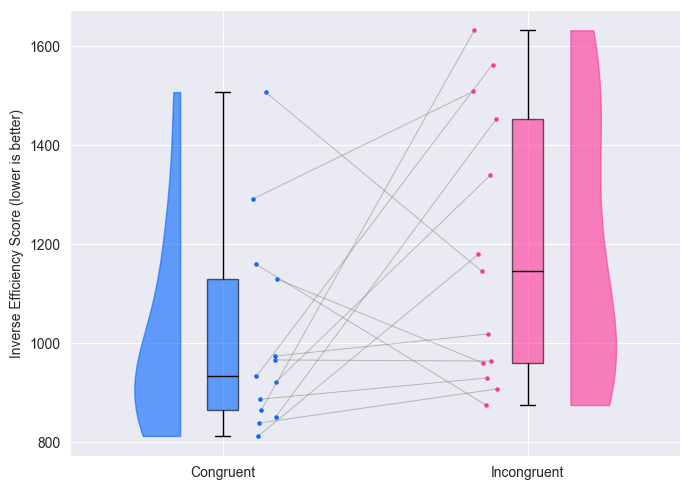

In [6]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_congruency
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted = IES_pivoted.rename_axis(None, axis=1)
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    IES_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES congruency'
)

   subject_id     session       stable     volatile
0     sub-802  session-01  1085.931227  1031.259785
1     sub-803  session-01   881.166791  1080.319513
2     sub-804  session-01  1157.634265  1195.715321
3     sub-805  session-01   963.921024   942.277156
4     sub-806  session-01   951.223401  1050.776428
5     sub-807  session-01  1361.622127  1427.159180
6     sub-808  session-01  1048.701170  1137.852800
7     sub-809  session-01   945.452135  1061.527346
8     sub-810  session-01  1334.113573  1285.622509
9     sub-811  session-01   835.015934   914.206823
10    sub-813  session-01   924.994743  1204.339965
11    sub-814  session-01   850.649691   981.584593
12    sub-815  session-01  1148.724004  1096.655533


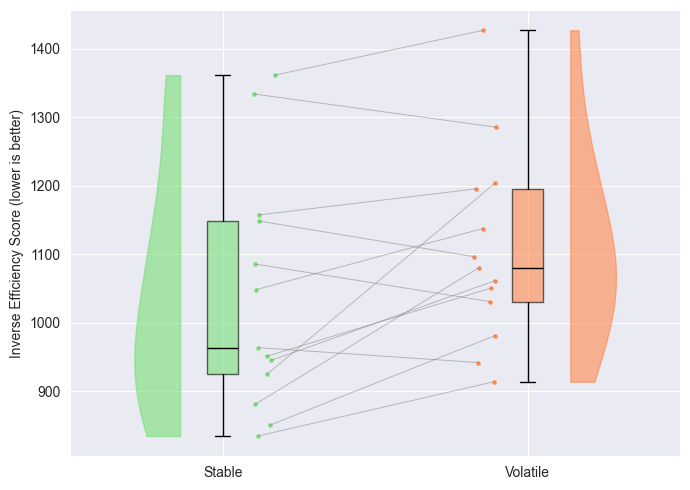

In [7]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted = IES_pivoted.rename_axis(None, axis=1)
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    IES_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES volatility',
    colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-802  session-01        847.454316          855.247626   
1     sub-803  session-01        872.541794         1082.800064   
2     sub-804  session-01        929.595368          937.270249   
3     sub-805  session-01        812.574351          813.205239   
4     sub-806  session-01        886.490548         1078.489116   
5     sub-807  session-01       1229.366215         1376.528926   
6     sub-808  session-01        873.300695          974.200542   
7     sub-809  session-01       1053.976575         1339.589809   
8     sub-810  session-01       1452.415365         1580.243761   
9     sub-811  session-01        827.452781          849.923042   
10    sub-813  session-01        997.915740         1293.030972   
11    sub-814  session-01        838.378378          944.095187   
12    sub-815  session-01        813.145013          921.801097   

    incongruent_stable  incongruent_volatile  
0          146

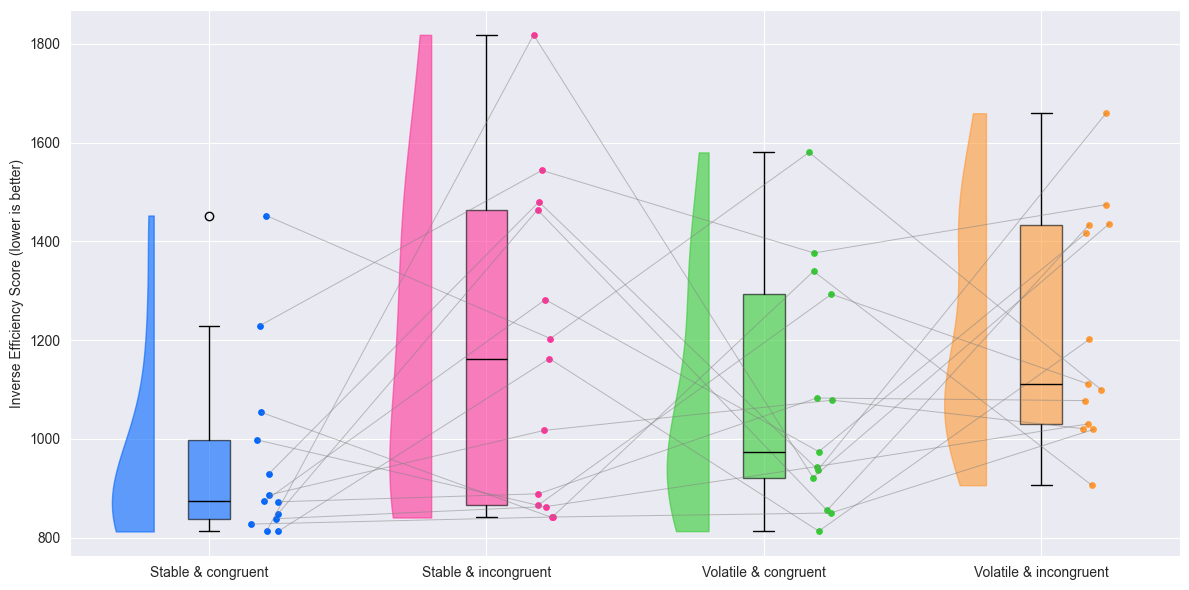

In [8]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_congruency_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency', 'volatility'],
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in IES_pivoted.columns
]
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    IES_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES congruency & volatility'
)

In [9]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe_all_sessions, ['congruency', 'volatility'])

    # Single-pass aggregation & reshape
    IES_dataframe = (
        IES_dataframe_congruency_volatility
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    IES_dataframe.columns = [
        f"{a}_{b}" if b else a
        for a, b in IES_dataframe.columns
    ]
    print(IES_dataframe)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        IES_dataframe,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='IES sessions, congruency & volatility'
    )

# LISAS
Linear Integrated Speed-Accuracy Score = mean RT in condition j (ms) + overall RT SD / overall proportion of errors SD * proportion of errors in condition j (0.10 for example)

In [10]:
LISAS_dataframe_sessions = utils.analysis_functions.calculate_LISAS(combined_results_dataframe)
LISAS_dataframe_congruency = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['congruency'])
LISAS_dataframe_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['volatility'])
LISAS_dataframe_congruency_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['congruency', 'volatility'])

In [11]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate LISAS for all sessions
    LISAS_dataframe_sessions = utils.analysis_functions.calculate_LISAS(combined_results_dataframe_all_sessions)

    # Single-pass aggregation & reshape
    LISAS_pivoted = (
        LISAS_dataframe_sessions
        .pivot_table(
            index=['subject_id'],
            columns=['session'],
            values='LISAS',
            aggfunc='mean'
        )
        .reset_index()
    )
    print(LISAS_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_4_groups(
        LISAS_pivoted,
        columns=['session-01', 'session-02', 'session-03', 'session-04'],
        output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS session'
    )

   subject_id     session   congruent  incongruent
0     sub-802  session-01  873.564713   852.928737
1     sub-803  session-01  832.696019   840.092990
2     sub-804  session-01  908.173349   909.465526
3     sub-805  session-01  806.853665   801.967412
4     sub-806  session-01  879.801266   882.168089
5     sub-807  session-01  991.195076   987.377783
6     sub-808  session-01  852.873271   844.810115
7     sub-809  session-01  852.304301   863.605678
8     sub-810  session-01  988.397018   977.486176
9     sub-811  session-01  778.322625   765.406965
10    sub-813  session-01  900.597006   900.242139
11    sub-814  session-01  815.802434   807.729634
12    sub-815  session-01  919.925264   905.961780


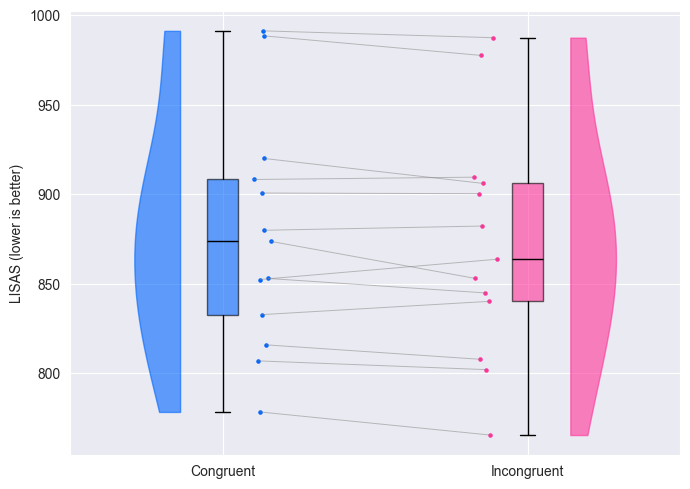

In [12]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_congruency
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted = LISAS_pivoted.rename_axis(None, axis=1)
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    LISAS_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS congruency'
)

   subject_id     session      stable    volatile
0     sub-802  session-01  856.887784  858.736289
1     sub-803  session-01  849.945259  829.211736
2     sub-804  session-01  901.765137  902.676277
3     sub-805  session-01  806.526593  801.025667
4     sub-806  session-01  886.087623  878.756636
5     sub-807  session-01  983.667635  994.927923
6     sub-808  session-01  846.634387  845.535877
7     sub-809  session-01  859.731484  854.886073
8     sub-810  session-01  990.252849  974.159082
9     sub-811  session-01  773.593548  770.605277
10    sub-813  session-01  921.525983  888.516334
11    sub-814  session-01  814.538357  809.557563
12    sub-815  session-01  900.873790  913.383777


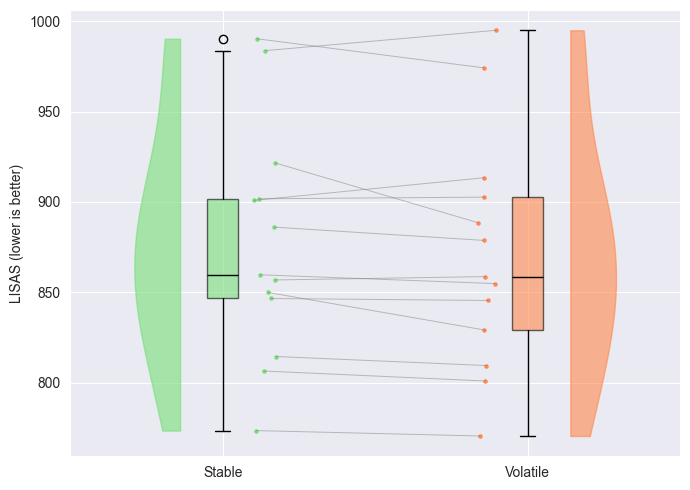

In [13]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted = LISAS_pivoted.rename_axis(None, axis=1)
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    LISAS_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS volatility',
        colours=['#77DF77', '#FF884D']
)

   subject_id     session  congruent_stable  congruent_volatile  \
0     sub-802  session-01        875.294409          871.970006   
1     sub-803  session-01        842.427591          828.984891   
2     sub-804  session-01        907.176203          909.055004   
3     sub-805  session-01        810.610832          802.866445   
4     sub-806  session-01        894.961598          872.979404   
5     sub-807  session-01        986.956334          997.502939   
6     sub-808  session-01        867.225407          842.385048   
7     sub-809  session-01        853.676694          852.855706   
8     sub-810  session-01        995.972469          978.872970   
9     sub-811  session-01        776.272854          780.038488   
10    sub-813  session-01        916.181637          892.511724   
11    sub-814  session-01        823.156114          810.257192   
12    sub-815  session-01        919.396482          920.341822   

    incongruent_stable  incongruent_volatile  
0           84

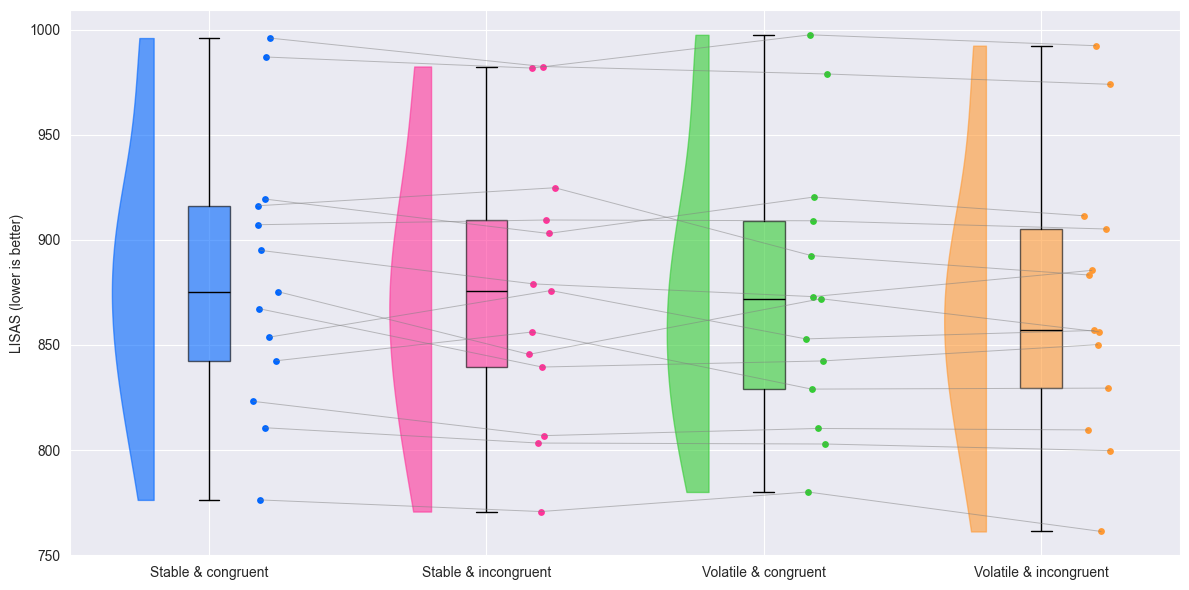

In [14]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_congruency_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency', 'volatility'],
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in LISAS_pivoted.columns
]
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    LISAS_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS congruency & volatility'
)

In [15]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    LISAS_dataframe_congruency_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe_all_sessions, ['congruency', 'volatility'])

    # Single-pass aggregation & reshape
    LISAS_dataframe = (
        LISAS_dataframe_congruency_volatility
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='LISAS',
            aggfunc='mean'
        )
        .reset_index()
    )
    LISAS_dataframe.columns = [
        f"{a}_{b}" if b else a
        for a, b in LISAS_dataframe.columns
    ]
    print(LISAS_dataframe)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        LISAS_dataframe,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS sessions, congruency & volatility'
    )

# Plot the relation between speed and accuracy
Quantile probability function

In [16]:
quadratic_trend = False

In [17]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'congruency'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session   congruency  mean_reaction_time  mean_performance
0     sub-802  session-01    congruent          715.723647          0.814815
1     sub-802  session-01  incongruent          780.461039          0.542208
2     sub-803  session-01    congruent          750.481707          0.765244
3     sub-803  session-01  incongruent          753.036145          0.774096
4     sub-804  session-01    congruent          714.592593          0.734568
5     sub-804  session-01  incongruent          735.297619          0.476190
6     sub-805  session-01    congruent          674.883523          0.806818
7     sub-805  session-01  incongruent          743.198052          0.623377
8     sub-806  session-01    congruent          783.240964          0.801205
9     sub-806  session-01  incongruent          821.228659          0.798780
10    sub-807  session-01    congruent          765.929664          0.568807
11    sub-807  session-01  incongruent          794.478916          0.490964

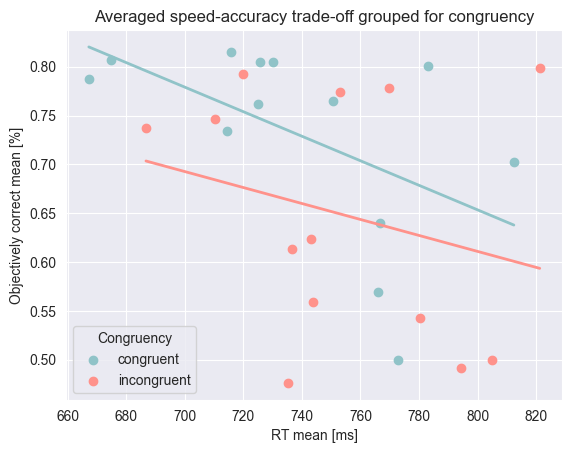

In [18]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'congruency'

# Define colours for each group
colour_map = {
    'congruent':   '#90C3C8',
    'incongruent': '#FF928B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for congruency'
ax.set_title(plot_name)
ax.legend(title='Congruency')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

In [19]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'volatility'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session volatility  mean_reaction_time  mean_performance
0     sub-802  session-01     stable          768.078488          0.683140
1     sub-802  session-01   volatile          721.847619          0.692063
2     sub-803  session-01     stable          755.298851          0.847701
3     sub-803  session-01   volatile          747.826923          0.682692
4     sub-804  session-01     stable          711.205882          0.602941
5     sub-804  session-01   volatile          739.931250          0.603125
6     sub-805  session-01     stable          721.901163          0.726744
7     sub-805  session-01   volatile          690.284810          0.715190
8     sub-806  session-01     stable          806.008721          0.843023
9     sub-806  session-01   volatile          797.886076          0.753165
10    sub-807  session-01     stable          786.459302          0.549419
11    sub-807  session-01   volatile          773.600000          0.507937
12    sub-808  session-01

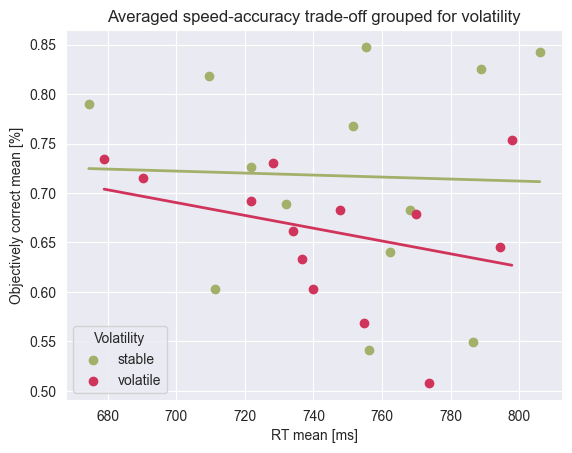

In [20]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'volatility'

# Define colours for each group
colour_map = {
    'stable':   '#A4AF69',
    'volatile': '#D1345B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for volatility'
ax.set_title(plot_name)
ax.legend(title='Volatility')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

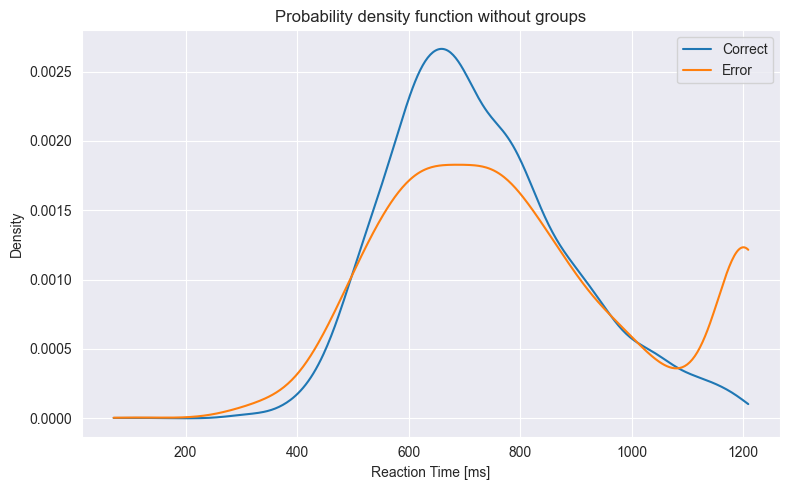

In [21]:
# assume `df` is your DataFrame
# split RTs by correctness
rts_correct = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 1, 'RT_ms']
rts_error   = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 0, 'RT_ms']

# compute KDEs
kde_correct = gaussian_kde(rts_correct)
kde_error   = gaussian_kde(rts_error)

# choose a common x‐axis range
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

# plot both densities
plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde_correct(x_vals), label='Correct')
plt.plot(x_vals, kde_error(  x_vals), label='Error')
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function without groups'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

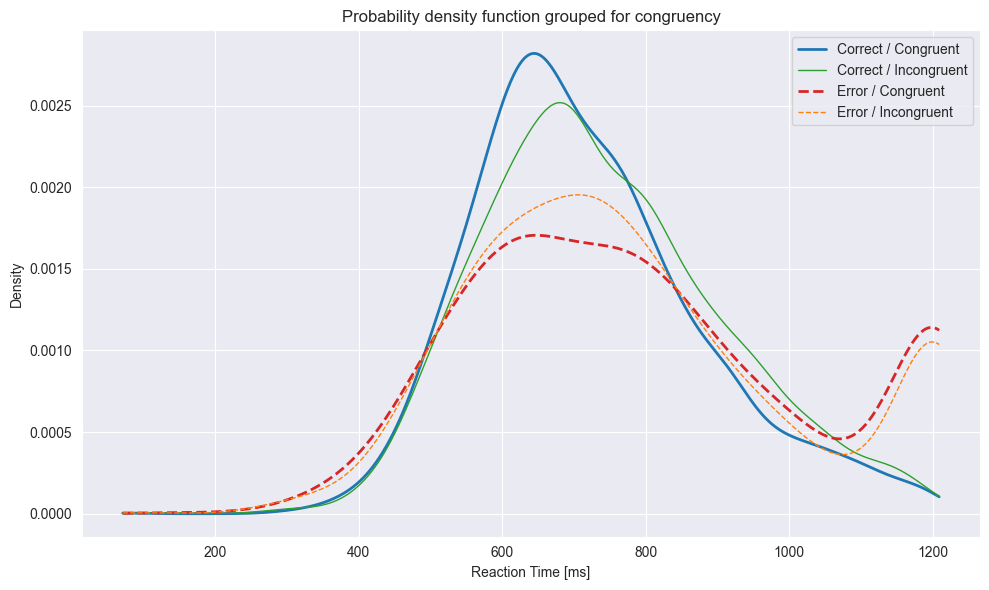

In [22]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['congruent', 'incongruent']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'congruent'):   'tab:blue',
    (1, 'incongruent'): 'tab:green',
    (0, 'congruent'):   'tab:red',
    (0, 'incongruent'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for cong in ['congruent', 'incongruent']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['congruency'] == cong)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {cong.capitalize()}"
        c = color_map[(obj_val, cong)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if cong == 'congruent' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for congruency'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

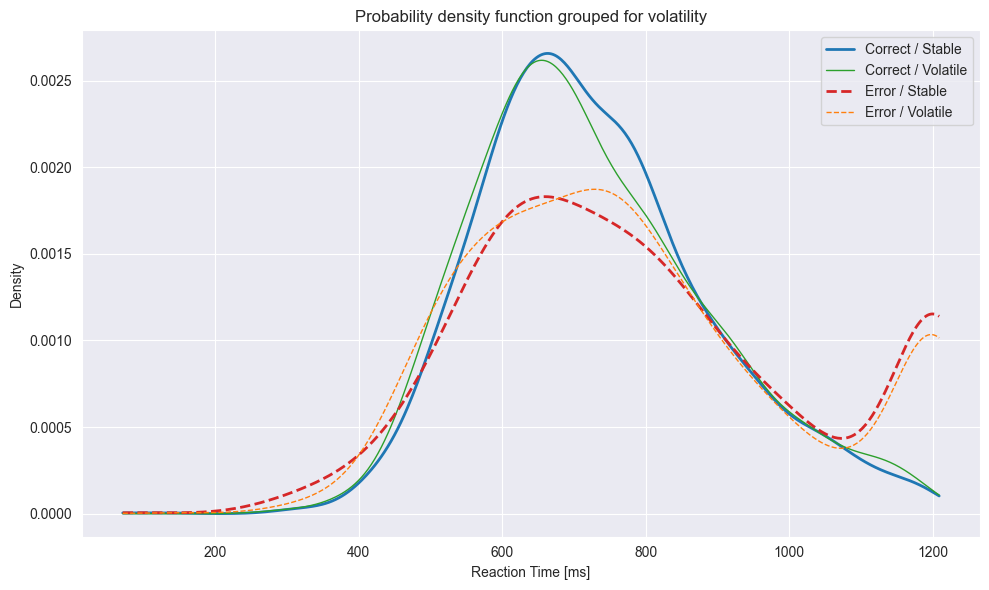

In [23]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['stable', 'volatile']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'stable'):   'tab:blue',
    (1, 'volatile'): 'tab:green',
    (0, 'stable'):   'tab:red',
    (0, 'volatile'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for volatility in ['stable', 'volatile']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['volatility'] == volatility)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {volatility.capitalize()}"
        c = color_map[(obj_val, volatility)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if volatility == 'stable' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for volatility'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

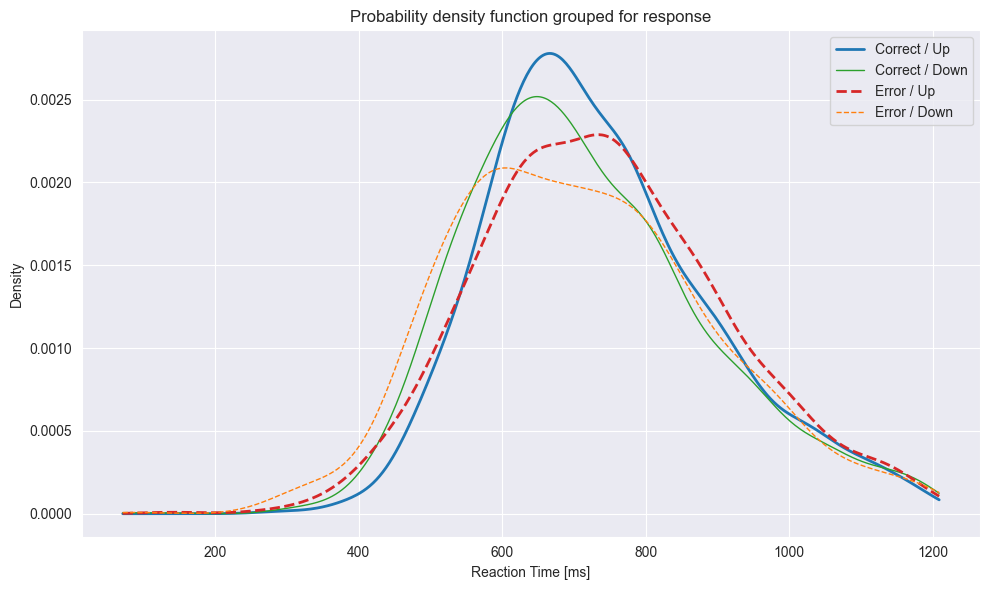

In [24]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['up', 'down']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'up'):   'tab:blue',
    (1, 'down'): 'tab:green',
    (0, 'up'):   'tab:red',
    (0, 'down'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for response_direction in ['up', 'down']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['response'] == response_direction)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {response_direction.capitalize()}"
        c = color_map[(obj_val, response_direction)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if response_direction == 'up' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for response'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()